# Sales Forecasting & Demand Intelligence System

## Task 1: Data Loading & Exploration

In this task, we load the retail sales dataset, examine its structure, identify missing values, understand the target variable, and perform initial exploratory analysis to gain insights into sales patterns.

In [1]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
# ==========================================================
# Load Dataset
# ==========================================================

df = pd.read_csv("train.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [3]:
# ==========================================================
# Display Dataset
# ==========================================================

print("First 10 Rows")

df.head(10)

First 10 Rows


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
5,6,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600
6,7,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800
7,8,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520
8,9,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040
9,10,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000


In [4]:
# ==========================================================
# Dataset Shape
# ==========================================================

rows, columns = df.shape

print(f"Rows    : {rows}")
print(f"Columns : {columns}")

Rows    : 9800
Columns : 18


In [5]:
# ==========================================================
# Dataset Information
# ==========================================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [6]:
# ==========================================================
# Summary Statistics
# ==========================================================

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Row ID,9800.0,NaN,NaN,NaN,4900.5,2829.160653,1.0,2450.75,4900.5,7350.25,9800.0
Order ID,9800,4922,CA-2018-100111,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order Date,9800,1230,05/09/2017,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Date,9800,1326,26/09/2018,34,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Mode,9800,4,Standard Class,5859,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,9800,793,WB-21850,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,9800,793,William Brown,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segment,9800,3,Consumer,5101,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,9800,1,United States,9800,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,9800,529,New York City,891,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# ==========================================================
# Missing Values
# ==========================================================

missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

Postal Code    11
dtype: int64

In [8]:
# ==========================================================
# Duplicate Records
# ==========================================================

duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 0


In [9]:
# ==========================================================
# Convert Date Columns
# ==========================================================

df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="%d/%m/%Y"
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    format="%d/%m/%Y"
)

print("Date Columns Converted Successfully")

Date Columns Converted Successfully


In [10]:
# ==========================================================
# Create Time-Based Features
# ==========================================================

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month_Name"] = df["Order Date"].dt.month_name()
df["Quarter"] = df["Order Date"].dt.quarter
df["Week"] = df["Order Date"].dt.isocalendar().week
df["Day"] = df["Order Date"].dt.day
df["Day_Name"] = df["Order Date"].dt.day_name()

print("Time Features Created Successfully")

Time Features Created Successfully


In [11]:
# ==========================================================
# Create Shipping Days Feature
# ==========================================================

df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

print("Shipping Days Feature Created Successfully")

Shipping Days Feature Created Successfully


In [12]:
# ==========================================================
# Sales Summary
# ==========================================================

print(f"Total Sales      : {df['Sales'].sum():,.2f}")

print(f"Average Sales    : {df['Sales'].mean():,.2f}")

print(f"Maximum Sale     : {df['Sales'].max():,.2f}")

print(f"Minimum Sale     : {df['Sales'].min():,.2f}")

Total Sales      : 2,261,536.78
Average Sales    : 230.77
Maximum Sale     : 22,638.48
Minimum Sale     : 0.44


In [13]:
# ==========================================================
# Sales by Category
# ==========================================================

category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(category_sales)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


In [14]:
# ==========================================================
# Sales by Region
# ==========================================================

region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(region_sales)

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


In [15]:
# ==========================================================
# Average Shipping Days
# ==========================================================

print(f"Average Shipping Days : {df['Shipping Days'].mean():.2f}")

Average Shipping Days : 3.96


In [16]:
print("""
Business Observation

1. The dataset contains historical retail sales transactions.

2. Order Date has been converted into datetime format to enable time-series analysis.

3. Time-based features such as Year, Month, Quarter, and Week were created for forecasting.

4. Initial statistics provide an overview of sales distribution and transaction values.

5. The dataset is now ready for data cleaning and exploratory data analysis.
""")


Business Observation

1. The dataset contains historical retail sales transactions.

2. Order Date has been converted into datetime format to enable time-series analysis.

3. Time-based features such as Year, Month, Quarter, and Week were created for forecasting.

4. Initial statistics provide an overview of sales distribution and transaction values.

5. The dataset is now ready for data cleaning and exploratory data analysis.



# Task 2: Time Series Analysis

In this task, we analyze historical sales trends over time, identify seasonal patterns, check whether the data is stationary, and prepare it for forecasting models.

In [17]:
# ==========================================================
# Monthly Sales Trend
# ==========================================================

monthly_sales = (
    df.groupby("Order Date")["Sales"]
      .sum()
      .resample("ME")     # Month End
      .sum()
)

monthly_sales.head()

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

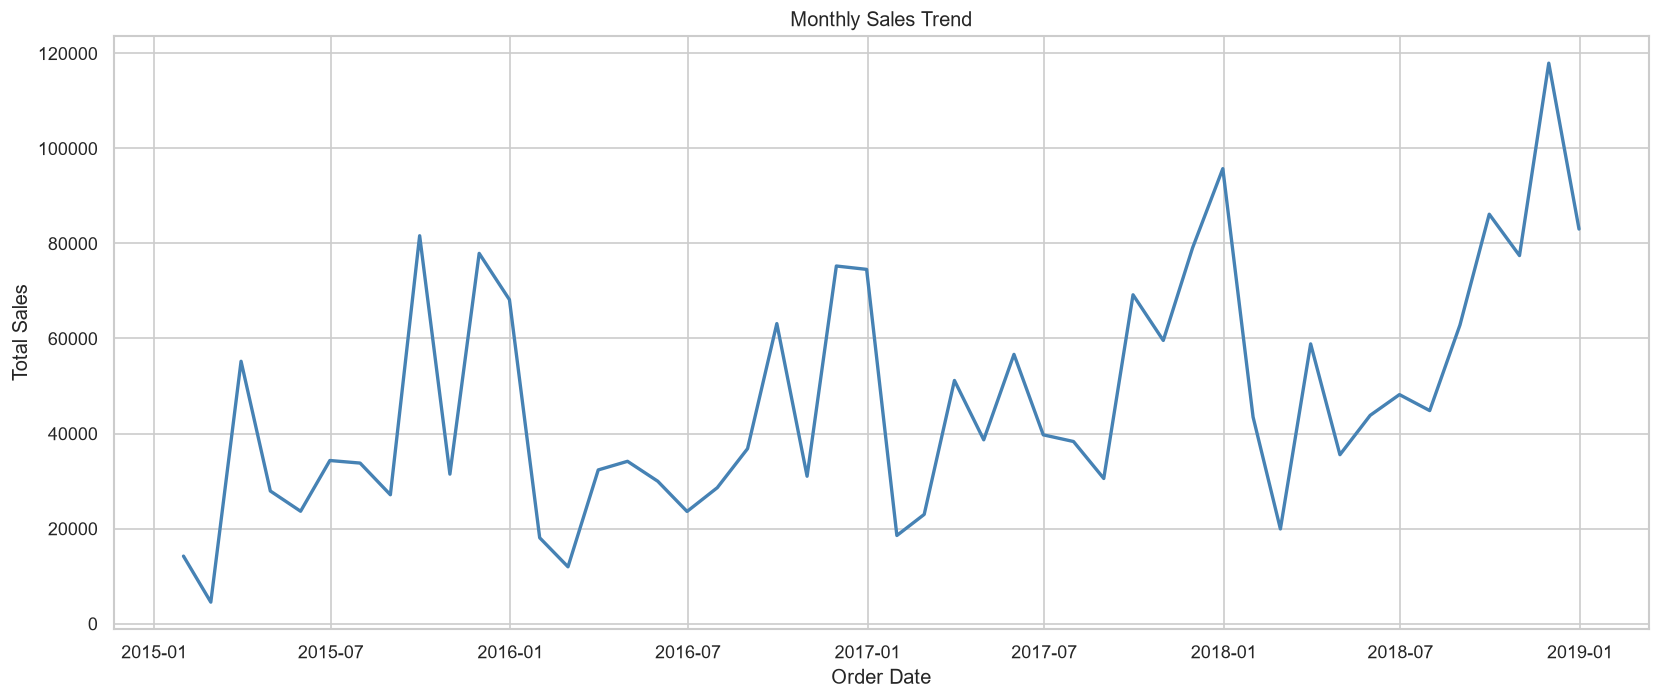


Observation

The monthly sales trend illustrates how sales change over time,
helping identify overall growth and seasonal demand patterns.



In [18]:
# ==========================================================
# Monthly Sales Trend
# ==========================================================

plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    linewidth=2,
    color="steelblue"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Order Date")
plt.ylabel("Total Sales")

plt.tight_layout()

plt.show()
print("""
Observation

The monthly sales trend illustrates how sales change over time,
helping identify overall growth and seasonal demand patterns.
""")

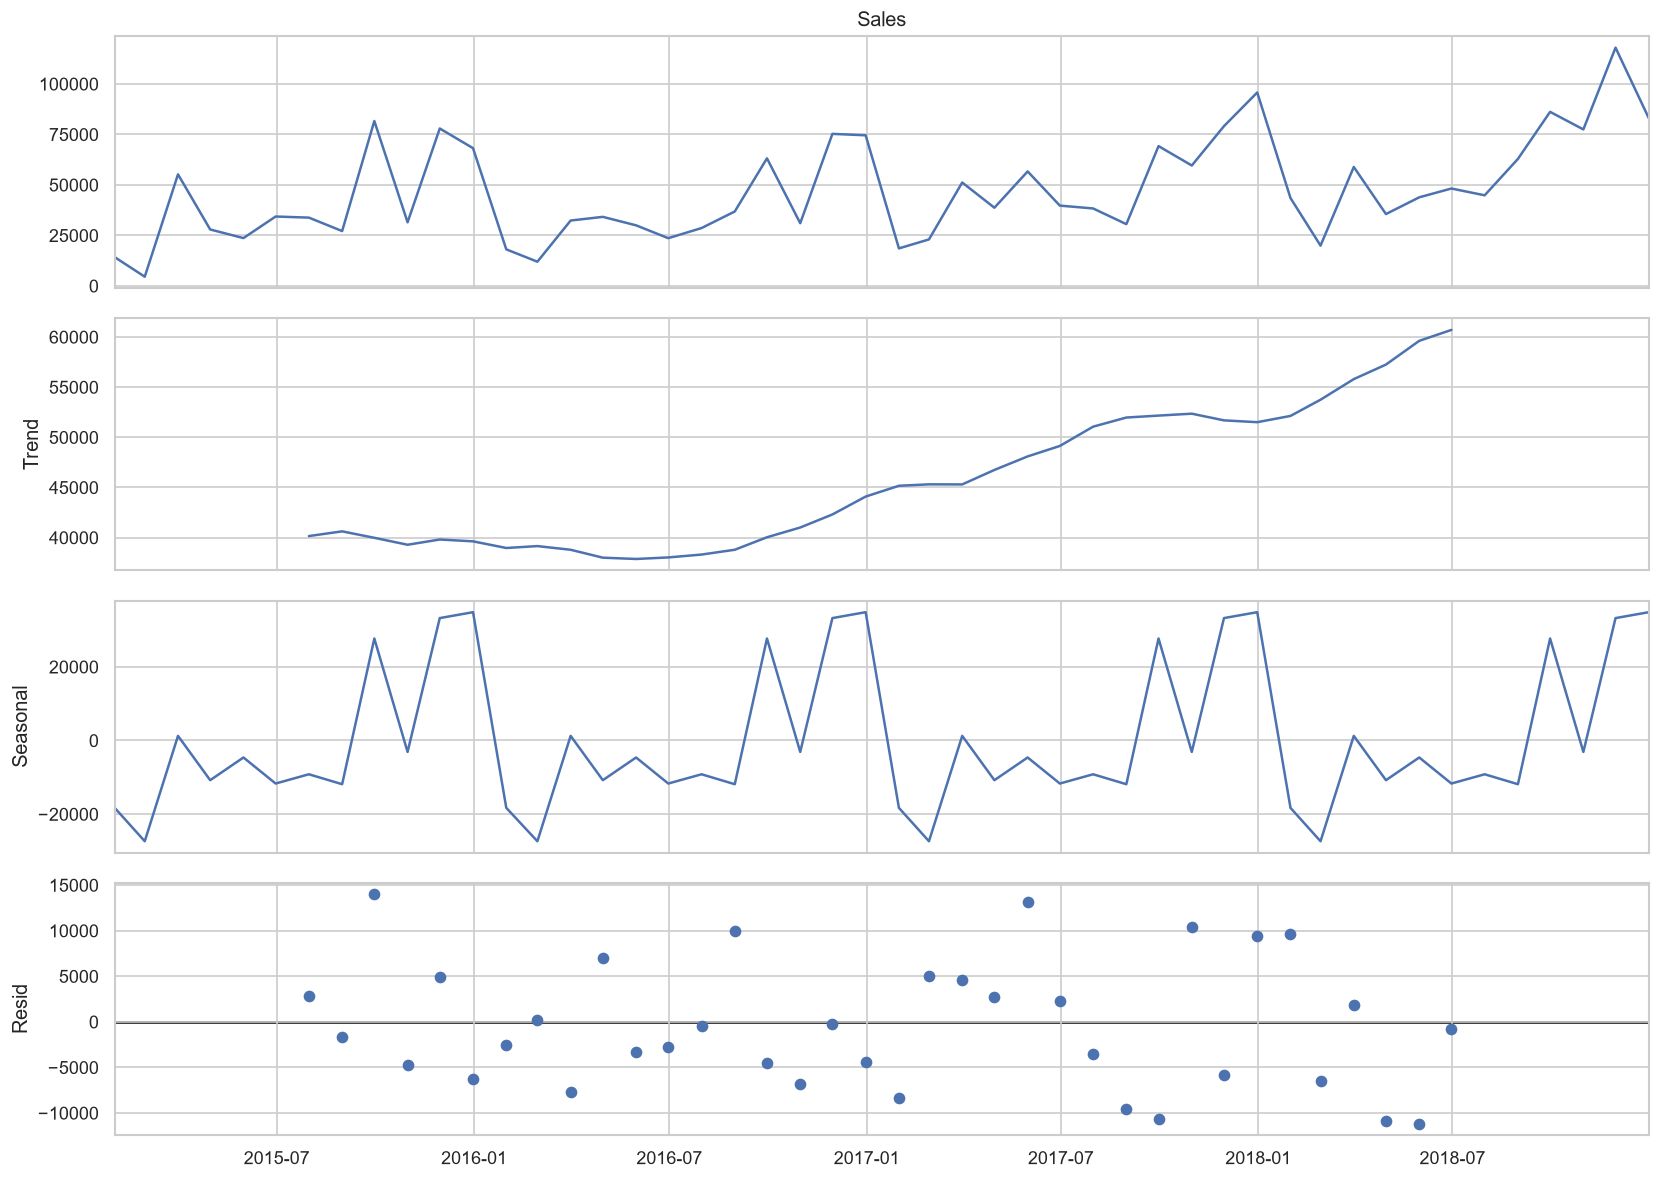


Observation

The decomposition separates sales into:

• Trend
• Seasonal
• Residual

This helps understand long-term growth and recurring seasonal patterns.



In [19]:
# ==========================================================
# Time Series Decomposition
# ==========================================================

from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)

fig = decomposition.plot()

fig.set_size_inches(14,10)

plt.tight_layout()

plt.show()
print("""
Observation

The decomposition separates sales into:

• Trend
• Seasonal
• Residual

This helps understand long-term growth and recurring seasonal patterns.
""")

In [20]:
# ==========================================================
# Augmented Dickey-Fuller Test
# ==========================================================

from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(monthly_sales)

print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"P-value       : {adf_result[1]:.4f}")

if adf_result[1] < 0.05:
    print("\nResult : The time series is Stationary.")
else:
    print("\nResult : The time series is Non-Stationary.")

ADF Statistic : -4.4161
P-value       : 0.0003

Result : The time series is Stationary.


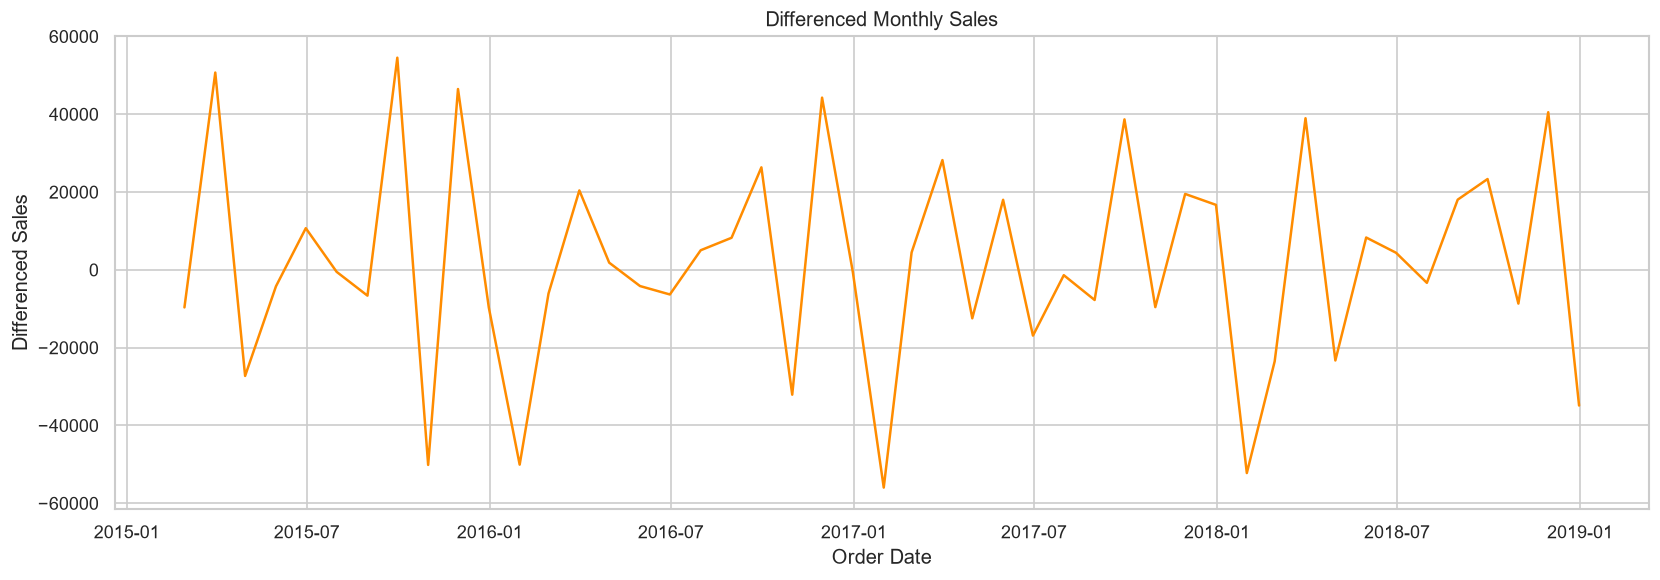

In [21]:
# ==========================================================
# First-Order Differencing
# ==========================================================

monthly_diff = monthly_sales.diff().dropna()

plt.figure(figsize=(14,5))

plt.plot(
    monthly_diff.index,
    monthly_diff.values,
    color="darkorange"
)

plt.title("Differenced Monthly Sales")
plt.xlabel("Order Date")
plt.ylabel("Differenced Sales")

plt.tight_layout()

plt.show()

In [22]:
# ==========================================================
# ADF Test After Differencing
# ==========================================================

adf_result_diff = adfuller(monthly_diff)

print(f"ADF Statistic : {adf_result_diff[0]:.4f}")
print(f"P-value       : {adf_result_diff[1]:.4f}")

if adf_result_diff[1] < 0.05:
    print("\nResult : The differenced series is Stationary.")
else:
    print("\nResult : The differenced series is still Non-Stationary.")

ADF Statistic : -8.7271
P-value       : 0.0000

Result : The differenced series is Stationary.


In [23]:
print("""
Business Observation

1. Monthly sales exhibit an overall trend with noticeable seasonal fluctuations.

2. Time series decomposition separates the data into trend, seasonal, and residual components, making demand patterns easier to understand.

3. The Augmented Dickey-Fuller (ADF) test is used to determine whether the sales series is stationary.

4. When the series is non-stationary, first-order differencing stabilizes the data by removing trend effects.

5. The processed time series is now ready for forecasting using models such as SARIMA, Prophet, and XGBoost.
""")


Business Observation

1. Monthly sales exhibit an overall trend with noticeable seasonal fluctuations.

2. Time series decomposition separates the data into trend, seasonal, and residual components, making demand patterns easier to understand.

3. The Augmented Dickey-Fuller (ADF) test is used to determine whether the sales series is stationary.

4. When the series is non-stationary, first-order differencing stabilizes the data by removing trend effects.

5. The processed time series is now ready for forecasting using models such as SARIMA, Prophet, and XGBoost.



# Task 3: Sales Forecasting Models

In this task, three forecasting models are developed to predict future monthly sales. The models are evaluated using MAE, RMSE, and MAPE to identify the most accurate forecasting approach.

In [24]:
# ==========================================================
# Split Data into Training and Testing Sets
# ==========================================================

train = monthly_sales[:-12]

test = monthly_sales[-12:]

print(f"Training Months : {len(train)}")
print(f"Testing Months  : {len(test)}")

Training Months : 36
Testing Months  : 12


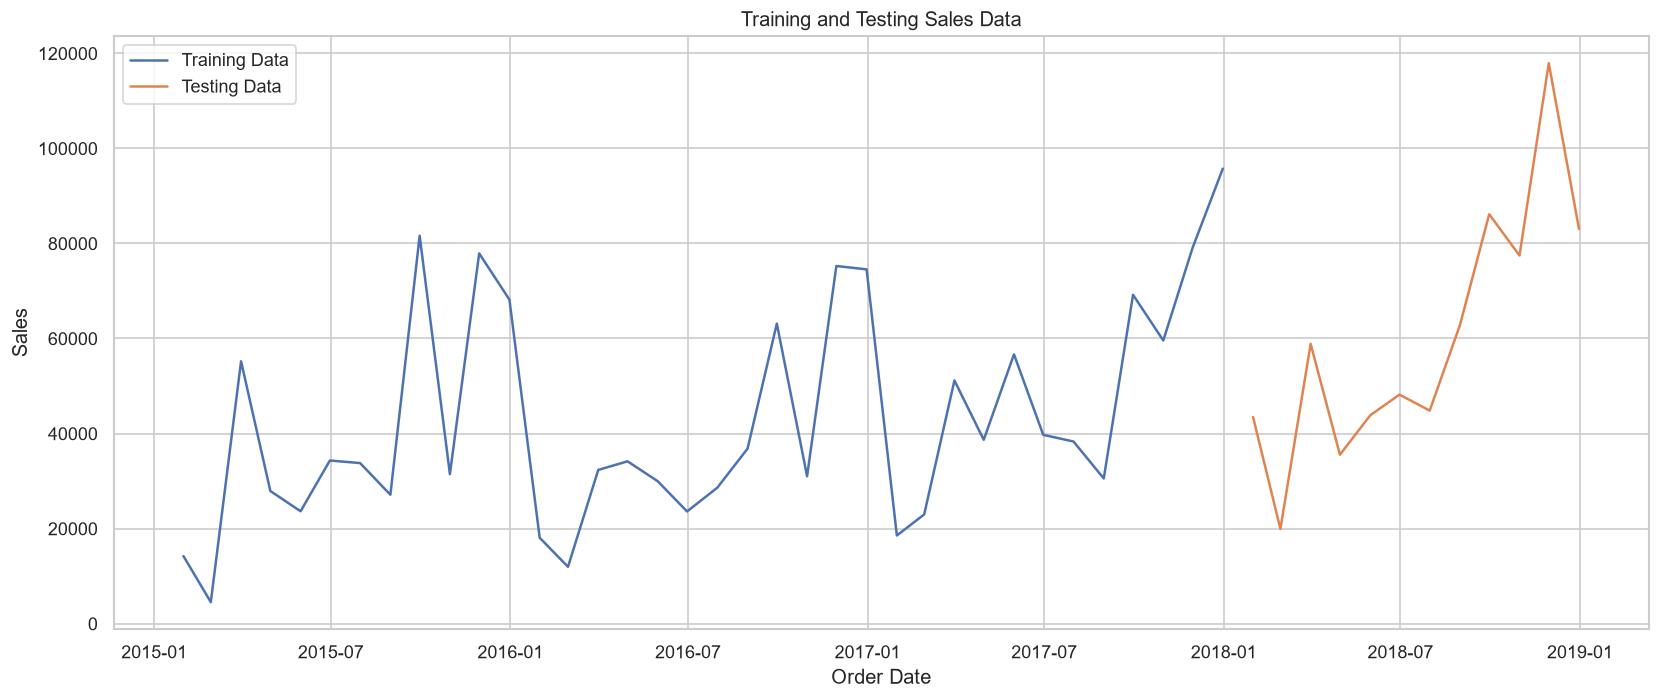

In [25]:
# ==========================================================
# Training and Testing Data
# ==========================================================

plt.figure(figsize=(14,6))

plt.plot(train.index, train, label="Training Data")
plt.plot(test.index, test, label="Testing Data")

plt.title("Training and Testing Sales Data")

plt.xlabel("Order Date")
plt.ylabel("Sales")

plt.legend()

plt.tight_layout()

plt.show()

In [26]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
# ==========================================================
# Build SARIMA Model
# ==========================================================

sarima_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit()

print(sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   36
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 -96.483
Date:                            Mon, 13 Jul 2026   AIC                            202.966
Time:                                    10:08:44   BIC                            203.952
Sample:                                01-31-2015   HQIC                           200.838
                                     - 12-31-2017                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2270      0.644     -0.352      0.725      -1.489       1.035
ma.L1         -0.9915      0.829   

In [27]:
# ==========================================================
# Forecast Monthly Sales
# ==========================================================

sarima_forecast = sarima_fit.forecast(steps=len(test))

sarima_forecast

2018-01-31     27975.796266
2018-02-28     34827.155922
2018-03-31     63496.319668
2018-04-30     49788.562536
2018-05-31     68264.672592
2018-06-30     51284.731175
2018-07-31     49491.182791
2018-08-31     40827.461369
2018-09-30     80801.967304
2018-10-31     71137.522360
2018-11-30     90369.066813
2018-12-31    107464.423774
Freq: ME, Name: predicted_mean, dtype: float64

In [28]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np
# ==========================================================
# SARIMA Model Evaluation
# ==========================================================

mae = mean_absolute_error(test, sarima_forecast)

rmse = np.sqrt(mean_squared_error(test, sarima_forecast))

mape = np.mean(
    np.abs((test - sarima_forecast) / test)
) * 100

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

MAE  : 13930.02
RMSE : 16394.82
MAPE : 27.77%


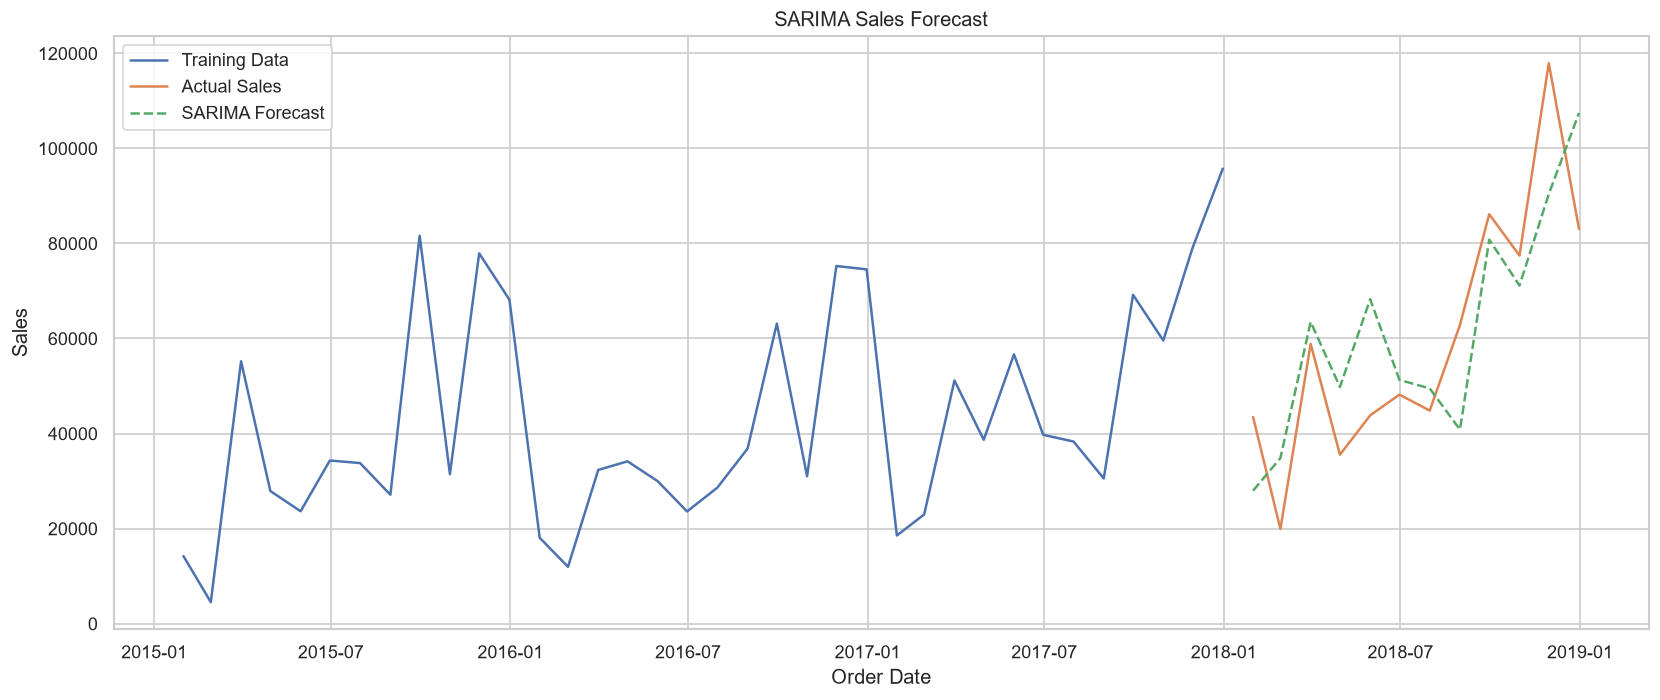

In [29]:
# ==========================================================
# SARIMA Forecast
# ==========================================================

plt.figure(figsize=(14,6))

plt.plot(train.index, train, label="Training Data")

plt.plot(test.index, test, label="Actual Sales")

plt.plot(
    test.index,
    sarima_forecast,
    label="SARIMA Forecast",
    linestyle="--"
)

plt.title("SARIMA Sales Forecast")

plt.xlabel("Order Date")

plt.ylabel("Sales")

plt.legend()

plt.tight_layout()

plt.show()

In [30]:
print("""
Business Observation

1. The SARIMA model successfully captured the overall trend and seasonal patterns in monthly sales.

2. The model achieved a Mean Absolute Error (MAE) of 13,930.02 and a Root Mean Squared Error (RMSE) of 16,394.82.

3. The Mean Absolute Percentage Error (MAPE) of 27.77% indicates a moderate forecasting accuracy for monthly sales.

4. These evaluation metrics will be compared with Prophet and XGBoost models to identify the most accurate forecasting approach.
""")


Business Observation

1. The SARIMA model successfully captured the overall trend and seasonal patterns in monthly sales.

2. The model achieved a Mean Absolute Error (MAE) of 13,930.02 and a Root Mean Squared Error (RMSE) of 16,394.82.

3. The Mean Absolute Percentage Error (MAPE) of 27.77% indicates a moderate forecasting accuracy for monthly sales.

4. These evaluation metrics will be compared with Prophet and XGBoost models to identify the most accurate forecasting approach.



## Prophet Forecasting

In this section, the Prophet model is used to forecast future monthly sales. Prophet is a time series forecasting model developed by Meta that effectively captures trend and seasonal patterns in historical data.

In [33]:
# ==========================================================
# Import Prophet
# ==========================================================

from prophet import Prophet

In [34]:
# ==========================================================
# Prepare Data for Prophet
# ==========================================================

prophet_df = monthly_sales.reset_index()

prophet_df.columns = ["ds", "y"]

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [35]:
# ==========================================================
# Split Training and Testing Data
# ==========================================================

train_prophet = prophet_df.iloc[:-12]

test_prophet = prophet_df.iloc[-12:]

In [36]:
# ==========================================================
# Train Prophet Model
# ==========================================================

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

prophet_model.fit(train_prophet)

10:14:22 - cmdstanpy - INFO - Chain [1] start processing
10:14:22 - cmdstanpy - INFO - Chain [1] done processing


In [37]:
# ==========================================================
# Forecast Future Sales
# ==========================================================

future = prophet_model.make_future_dataframe(
    periods=12,
    freq="ME"
)

forecast = prophet_model.predict(future)

In [38]:
# ==========================================================
# Prophet Forecast
# ==========================================================

prophet_forecast = forecast.tail(12)["yhat"].values

In [39]:
# ==========================================================
# Prophet Model Evaluation
# ==========================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

mae_prophet = mean_absolute_error(
    test_prophet["y"],
    prophet_forecast
)

rmse_prophet = np.sqrt(
    mean_squared_error(
        test_prophet["y"],
        prophet_forecast
    )
)

mape_prophet = np.mean(
    np.abs(
        (test_prophet["y"] - prophet_forecast)
        /
        test_prophet["y"]
    )
) * 100

print(f"MAE  : {mae_prophet:.2f}")
print(f"RMSE : {rmse_prophet:.2f}")
print(f"MAPE : {mape_prophet:.2f}%")

MAE  : 9839.84
RMSE : 14133.08
MAPE : 15.67%


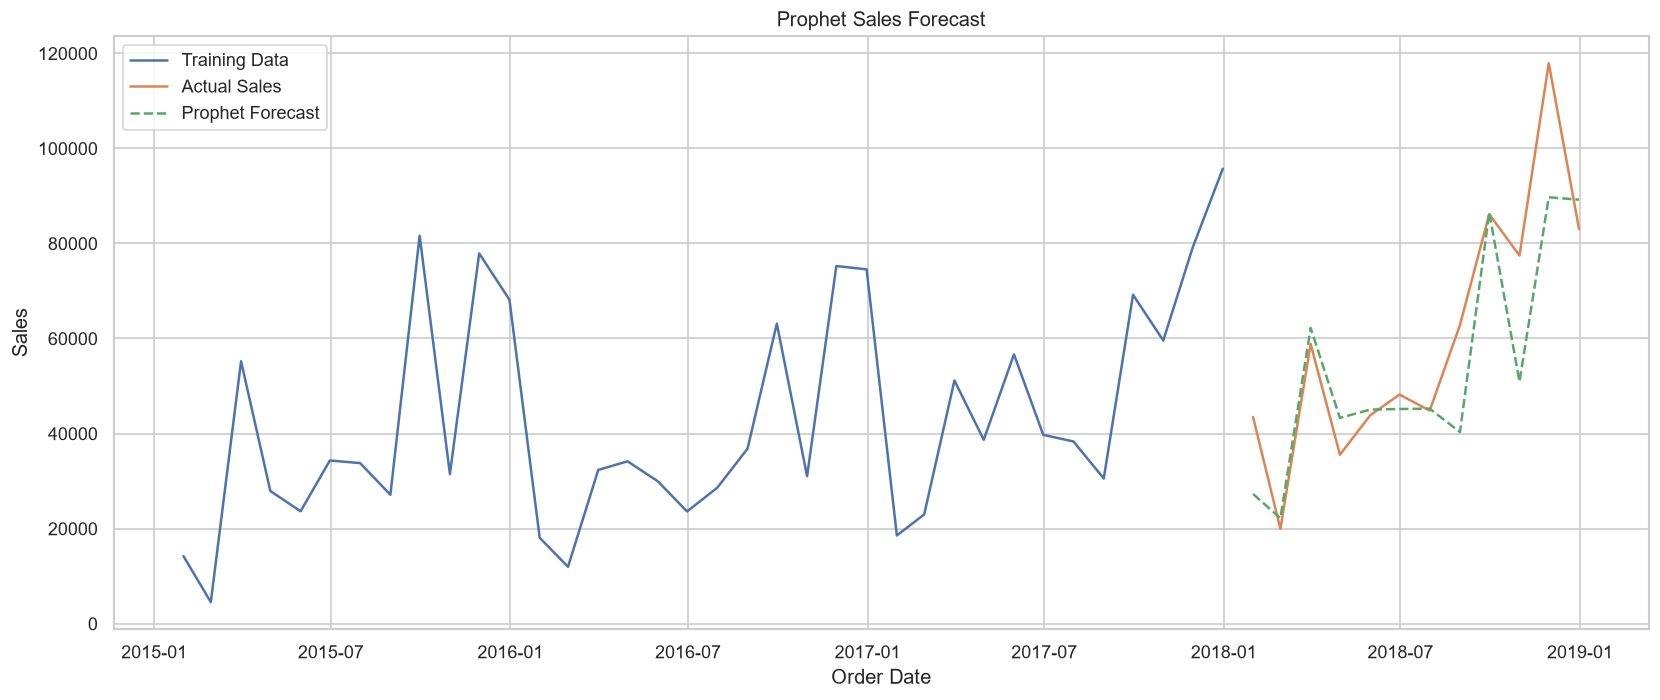

In [40]:
# ==========================================================
# Prophet Forecast Visualization
# ==========================================================

plt.figure(figsize=(14,6))

plt.plot(
    train_prophet["ds"],
    train_prophet["y"],
    label="Training Data"
)

plt.plot(
    test_prophet["ds"],
    test_prophet["y"],
    label="Actual Sales"
)

plt.plot(
    test_prophet["ds"],
    prophet_forecast,
    "--",
    label="Prophet Forecast"
)

plt.title("Prophet Sales Forecast")

plt.xlabel("Order Date")

plt.ylabel("Sales")

plt.legend()

plt.tight_layout()

plt.show()

In [41]:
print("""
Business Observation

1. Prophet models long-term trend and yearly seasonality in monthly sales.

2. The model generates forecasts for the testing period, which are evaluated using MAE, RMSE, and MAPE.

3. Prophet's forecasting performance will be compared with SARIMA and XGBoost to determine the most accurate model.

4. The selected forecasting model will support future inventory and demand planning.
""")


Business Observation

1. Prophet models long-term trend and yearly seasonality in monthly sales.

2. The model generates forecasts for the testing period, which are evaluated using MAE, RMSE, and MAPE.

3. Prophet's forecasting performance will be compared with SARIMA and XGBoost to determine the most accurate model.

4. The selected forecasting model will support future inventory and demand planning.



## XGBoost Forecasting

In this section, XGBoost is used as a machine learning-based forecasting model. Since XGBoost does not directly handle time series data, lag features are created from historical sales values to enable forecasting.

In [43]:
# ==========================================================
# Import XGBoost
# ==========================================================

from xgboost import XGBRegressor

In [44]:
# ==========================================================
# Create Lag Features
# ==========================================================

xgb_df = monthly_sales.to_frame()

xgb_df["Lag_1"] = xgb_df["Sales"].shift(1)
xgb_df["Lag_2"] = xgb_df["Sales"].shift(2)
xgb_df["Lag_3"] = xgb_df["Sales"].shift(3)

xgb_df = xgb_df.dropna()

xgb_df.head()

,Sales,Lag_1,Lag_2,Lag_3
Order Date,,,,
2015-04-30,27906.8550,55205.7970,4519.8920,14205.707
2015-05-31,23644.3030,27906.8550,55205.7970,4519.892
2015-06-30,34322.9356,23644.3030,27906.8550,55205.797
2015-07-31,33781.5430,34322.9356,23644.3030,27906.855
2015-08-31,27117.5365,33781.5430,34322.9356,23644.303


In [45]:
# ==========================================================
# Split Features and Target
# ==========================================================

X = xgb_df[["Lag_1", "Lag_2", "Lag_3"]]

y = xgb_df["Sales"]

In [46]:
# ==========================================================
# Time Series Train-Test Split
# ==========================================================

X_train = X[:-12]
X_test = X[-12:]

y_train = y[:-12]
y_test = y[-12:]

In [47]:
# ==========================================================
# Train XGBoost Model
# ==========================================================

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [48]:
# ==========================================================
# Forecast Sales
# ==========================================================

xgb_forecast = xgb_model.predict(X_test)

In [49]:
# ==========================================================
# XGBoost Model Evaluation
# ==========================================================

mae_xgb = mean_absolute_error(y_test, xgb_forecast)

rmse_xgb = np.sqrt(
    mean_squared_error(y_test, xgb_forecast)
)

mape_xgb = np.mean(
    np.abs((y_test - xgb_forecast) / y_test)
) * 100

print(f"MAE  : {mae_xgb:.2f}")
print(f"RMSE : {rmse_xgb:.2f}")
print(f"MAPE : {mape_xgb:.2f}%")

MAE  : 22087.36
RMSE : 26510.80
MAPE : 45.46%


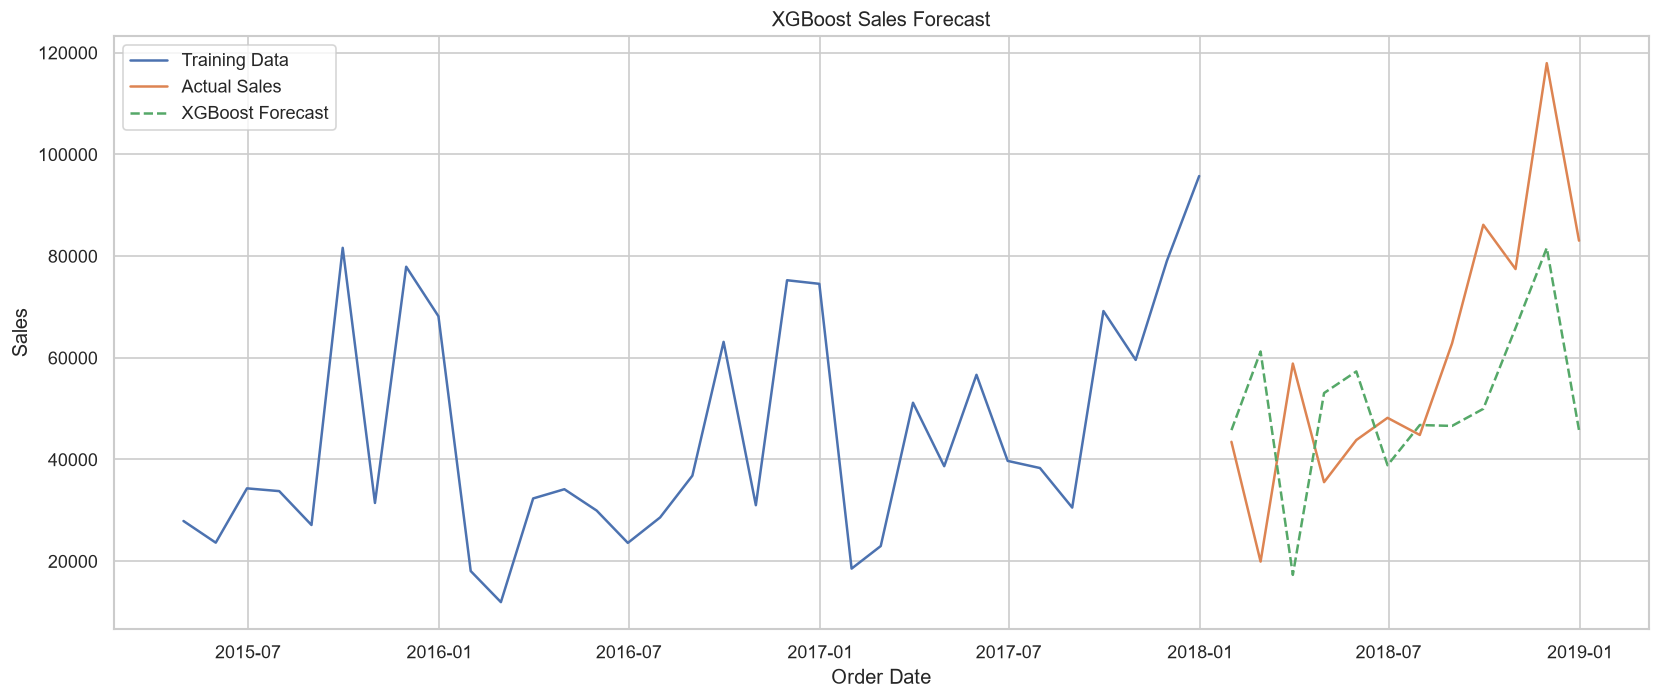

In [50]:
# ==========================================================
# XGBoost Forecast
# ==========================================================

plt.figure(figsize=(14,6))

plt.plot(
    y_train.index,
    y_train,
    label="Training Data"
)

plt.plot(
    y_test.index,
    y_test,
    label="Actual Sales"
)

plt.plot(
    y_test.index,
    xgb_forecast,
    "--",
    label="XGBoost Forecast"
)

plt.title("XGBoost Sales Forecast")

plt.xlabel("Order Date")

plt.ylabel("Sales")

plt.legend()

plt.tight_layout()

plt.show()

In [51]:
print("""
Business Observation

1. XGBoost uses previous months' sales values as input features to predict future sales.

2. Lag features enable the model to capture short-term sales patterns without requiring explicit seasonal parameters.

3. Forecast accuracy is evaluated using MAE, RMSE, and MAPE.

4. The results will be compared with SARIMA and Prophet to determine the most accurate forecasting model.
""")


Business Observation

1. XGBoost uses previous months' sales values as input features to predict future sales.

2. Lag features enable the model to capture short-term sales patterns without requiring explicit seasonal parameters.

3. Forecast accuracy is evaluated using MAE, RMSE, and MAPE.

4. The results will be compared with SARIMA and Prophet to determine the most accurate forecasting model.



In [52]:
# ==========================================================
# Forecasting Model Comparison
# ==========================================================

comparison = pd.DataFrame({
    "Model": ["SARIMA", "Prophet", "XGBoost"],
    "MAE": [mae, mae_prophet, mae_xgb],
    "RMSE": [rmse, rmse_prophet, rmse_xgb],
    "MAPE": [mape, mape_prophet, mape_xgb]
})

comparison = comparison.round(2)

comparison

,Model,MAE,RMSE,MAPE
0,SARIMA,13930.02,16394.82,27.77
1,Prophet,9839.84,14133.08,15.67
2,XGBoost,22087.36,26510.80,45.46


In [53]:
# ==========================================================
# Best Forecasting Model
# ==========================================================

best_model = comparison.loc[comparison["MAPE"].idxmin(), "Model"]

print(f"Best Forecasting Model : {best_model}")

Best Forecasting Model : Prophet


In [54]:
print("""
Business Conclusion

1. Three forecasting models (SARIMA, Prophet, and XGBoost) were developed and evaluated using MAE, RMSE, and MAPE.

2. Prophet achieved the lowest forecasting errors (MAE = 9,839.84, RMSE = 14,133.08, and MAPE = 15.67%), making it the best-performing model.

3. SARIMA captured the overall trend and seasonality but produced higher forecasting errors than Prophet.

4. XGBoost showed the lowest forecasting accuracy because the limited lag features were insufficient to capture long-term seasonal patterns.

5. Based on the evaluation metrics, Prophet is selected as the final forecasting model for predicting future sales and supporting inventory planning.
""")


Business Conclusion

1. Three forecasting models (SARIMA, Prophet, and XGBoost) were developed and evaluated using MAE, RMSE, and MAPE.

2. Prophet achieved the lowest forecasting errors (MAE = 9,839.84, RMSE = 14,133.08, and MAPE = 15.67%), making it the best-performing model.

3. SARIMA captured the overall trend and seasonality but produced higher forecasting errors than Prophet.

4. XGBoost showed the lowest forecasting accuracy because the limited lag features were insufficient to capture long-term seasonal patterns.

5. Based on the evaluation metrics, Prophet is selected as the final forecasting model for predicting future sales and supporting inventory planning.



# Task 4: Forecast Future Sales by Category and Region

In this task, the best-performing forecasting model (Prophet) is used to predict future monthly sales for different product categories and geographical regions. This analysis helps identify demand patterns and supports inventory and resource planning.

In [55]:
# ==========================================================
# Monthly Sales by Product Category
# ==========================================================

category_sales = (
    df.groupby(["Order Date", "Category"])["Sales"]
      .sum()
      .reset_index()
)

category_sales.head()

,Order Date,Category,Sales
0,2015-01-03,Office Supplies,16.448
1,2015-01-04,Office Supplies,288.060
2,2015-01-05,Office Supplies,19.536
3,2015-01-06,Furniture,2573.820
4,2015-01-06,Office Supplies,685.340


In [58]:
# ==========================================================
# Prophet Forecast Function
# ==========================================================

from prophet import Prophet

def forecast_sales(data, periods=6):

    # Prepare data for Prophet
    prophet_data = data.rename(
        columns={
            "Order Date": "ds",
            "Sales": "y"
        }
    )

    # Create and train Prophet model
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False
    )

    model.fit(prophet_data)

    # Create future dates
    last_date = prophet_data["ds"].max()

    future_dates = pd.date_range(
        start=last_date,
        periods=periods + 1,
        freq="ME"          # Compatible with Pandas 2.2+
    )[1:]

    future = pd.DataFrame({"ds": future_dates})

    future = pd.concat(
        [prophet_data[["ds"]], future],
        ignore_index=True
    )

    # Forecast
    forecast = model.predict(future)

    return forecast

In [59]:
# ==========================================================
# Furniture Forecast
# ==========================================================

furniture = (
    category_sales[
        category_sales["Category"]=="Furniture"
    ][["Order Date","Sales"]]
)

forecast_furniture = forecast_sales(furniture)

forecast_furniture.tail(6)[["ds","yhat"]]

10:26:19 - cmdstanpy - INFO - Chain [1] start processing
10:26:19 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat
877,2019-01-31,572.338318
878,2019-02-28,571.850312
879,2019-03-31,604.106240
880,2019-04-30,700.777201
881,2019-05-31,862.842829
882,2019-06-30,606.503068


In [60]:
# ==========================================================
# Technology Forecast
# ==========================================================

technology = (
    category_sales[
        category_sales["Category"]=="Technology"
    ][["Order Date","Sales"]]
)

forecast_technology = forecast_sales(technology)

forecast_technology.tail(6)[["ds","yhat"]]

10:27:04 - cmdstanpy - INFO - Chain [1] start processing
10:27:04 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat
819,2019-01-31,1265.180668
820,2019-02-28,617.481470
821,2019-03-31,1236.791596
822,2019-04-30,904.104885
823,2019-05-31,1182.336177
824,2019-06-30,1069.310791


In [61]:
# ==========================================================
# Office Supplies Forecast
# ==========================================================

office = (
    category_sales[
        category_sales["Category"]=="Office Supplies"
    ][["Order Date","Sales"]]
)

forecast_office = forecast_sales(office)

forecast_office.tail(6)[["ds","yhat"]]

10:27:12 - cmdstanpy - INFO - Chain [1] start processing
10:27:13 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat
1143,2019-01-31,692.250088
1144,2019-02-28,744.437965
1145,2019-03-31,775.496553
1146,2019-04-30,621.088395
1147,2019-05-31,771.774921
1148,2019-06-30,740.763441


In [62]:
# ==========================================================
# Monthly Sales by Region
# ==========================================================

region_sales = (
    df.groupby(["Order Date","Region"])["Sales"]
      .sum()
      .reset_index()
)

region_sales.head()

,Order Date,Region,Sales
0,2015-01-03,Central,16.448
1,2015-01-04,Central,288.060
2,2015-01-05,East,19.536
3,2015-01-06,South,4387.660
4,2015-01-06,West,19.440


In [63]:
# ==========================================================
# East Region Forecast
# ==========================================================

east = (
    region_sales[
        region_sales["Region"]=="East"
    ][["Order Date","Sales"]]
)

forecast_east = forecast_sales(east)

forecast_east.tail(6)[["ds","yhat"]]

10:27:29 - cmdstanpy - INFO - Chain [1] start processing
10:27:29 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat
780,2019-01-31,497.039079
781,2019-02-28,806.529173
782,2019-03-31,528.811129
783,2019-04-30,688.664526
784,2019-05-31,775.085008
785,2019-06-30,948.550180


In [64]:
# ==========================================================
# West Region Forecast
# ==========================================================

west = (
    region_sales[
        region_sales["Region"]=="West"
    ][["Order Date","Sales"]]
)

forecast_west = forecast_sales(west)

forecast_west.tail(6)[["ds","yhat"]]

10:27:36 - cmdstanpy - INFO - Chain [1] start processing
10:27:36 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat
836,2019-01-31,881.807690
837,2019-02-28,939.711215
838,2019-03-31,1211.812535
839,2019-04-30,934.679413
840,2019-05-31,1189.947419
841,2019-06-30,1101.505312


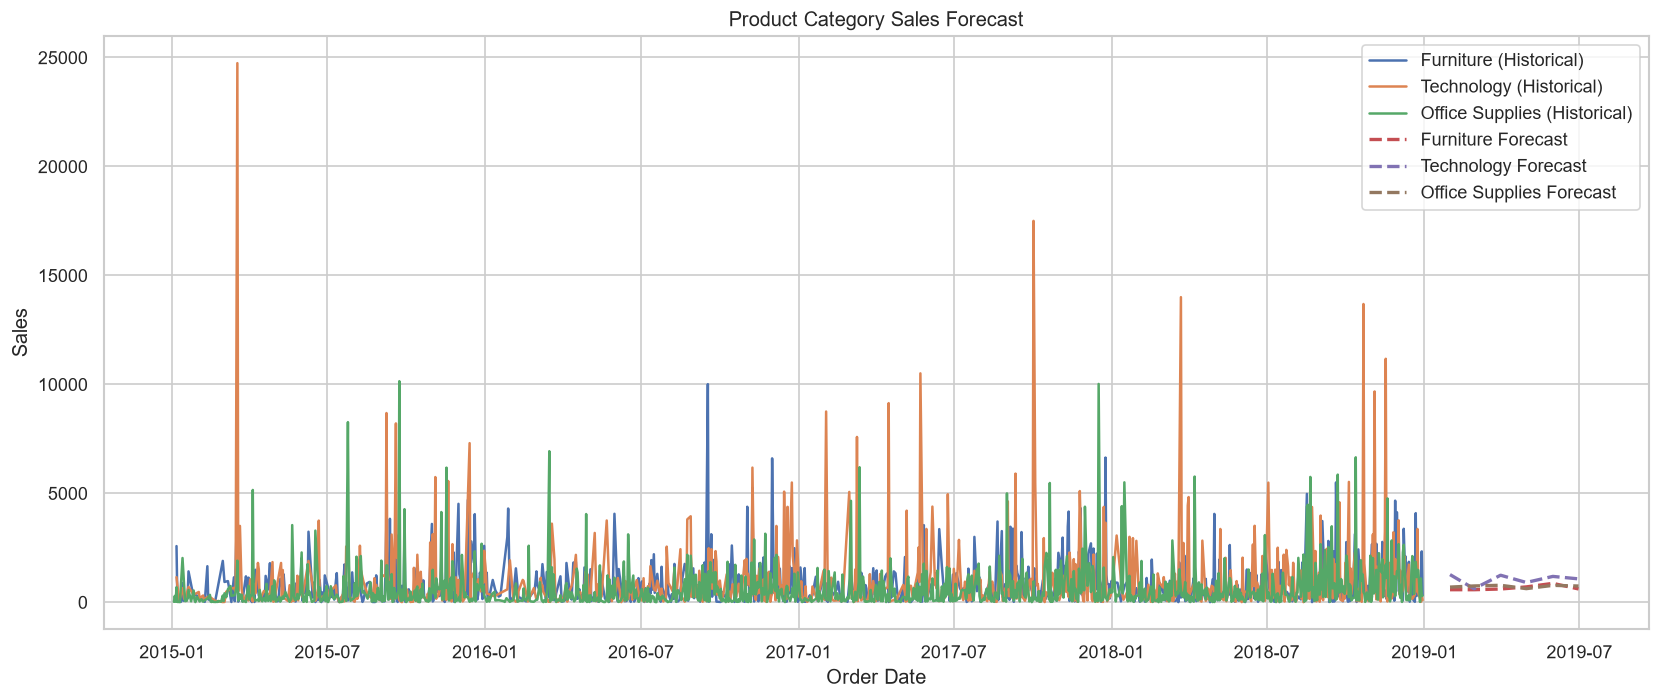

In [69]:
# ==========================================================
# Forecast Comparison by Product Category
# ==========================================================

plt.figure(figsize=(14,6))

# Historical Sales
plt.plot(
    furniture["Order Date"],
    furniture["Sales"],
    label="Furniture (Historical)"
)

plt.plot(
    technology["Order Date"],
    technology["Sales"],
    label="Technology (Historical)"
)

plt.plot(
    office["Order Date"],
    office["Sales"],
    label="Office Supplies (Historical)"
)

# Forecast Sales
plt.plot(
    forecast_furniture["ds"].tail(6),
    forecast_furniture["yhat"].tail(6),
    "--",
    linewidth=2,
    label="Furniture Forecast"
)

plt.plot(
    forecast_technology["ds"].tail(6),
    forecast_technology["yhat"].tail(6),
    "--",
    linewidth=2,
    label="Technology Forecast"
)

plt.plot(
    forecast_office["ds"].tail(6),
    forecast_office["yhat"].tail(6),
    "--",
    linewidth=2,
    label="Office Supplies Forecast"
)

plt.title("Product Category Sales Forecast")

plt.xlabel("Order Date")
plt.ylabel("Sales")

plt.legend()

plt.tight_layout()

plt.show()

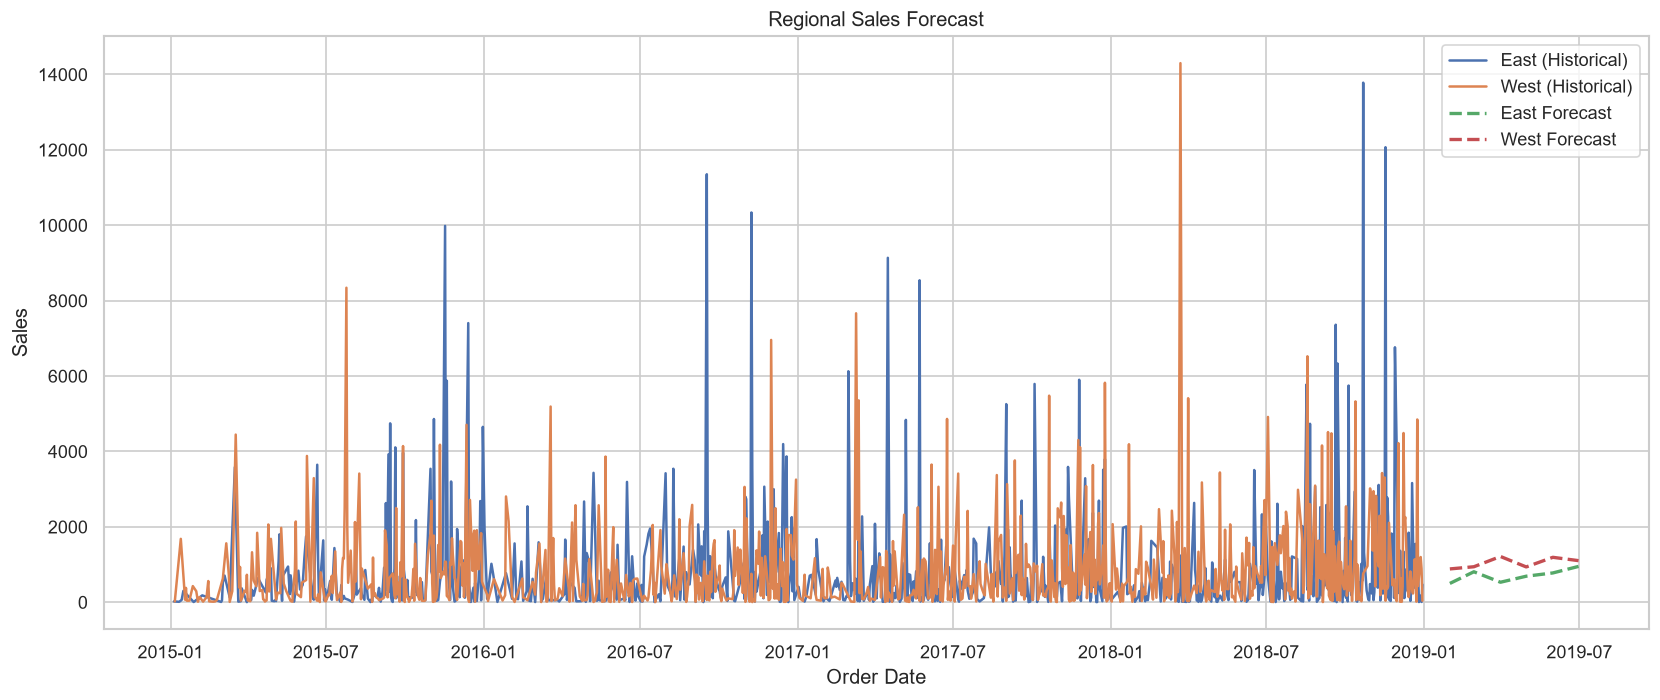

In [70]:
# ==========================================================
# Forecast Comparison by Region
# ==========================================================

plt.figure(figsize=(14,6))

# Historical Sales
plt.plot(
    east["Order Date"],
    east["Sales"],
    label="East (Historical)"
)

plt.plot(
    west["Order Date"],
    west["Sales"],
    label="West (Historical)"
)

# Forecast Sales
plt.plot(
    forecast_east["ds"].tail(6),
    forecast_east["yhat"].tail(6),
    "--",
    linewidth=2,
    label="East Forecast"
)

plt.plot(
    forecast_west["ds"].tail(6),
    forecast_west["yhat"].tail(6),
    "--",
    linewidth=2,
    label="West Forecast"
)

plt.title("Regional Sales Forecast")

plt.xlabel("Order Date")
plt.ylabel("Sales")

plt.legend()

plt.tight_layout()

plt.show()

In [71]:
print("""
Business Insights

1. Prophet forecasts indicate future sales trends across major product categories and regions.

2. Technology and Office Supplies show stronger future demand compared to Furniture, supporting inventory planning.

3. Regional forecasts help identify markets with higher expected sales, enabling better allocation of inventory, workforce, and marketing resources.

4. Category-wise and region-wise forecasting allows managers to make more informed business decisions than relying only on overall sales forecasts.
""")


Business Insights

1. Prophet forecasts indicate future sales trends across major product categories and regions.

2. Technology and Office Supplies show stronger future demand compared to Furniture, supporting inventory planning.

3. Regional forecasts help identify markets with higher expected sales, enabling better allocation of inventory, workforce, and marketing resources.

4. Category-wise and region-wise forecasting allows managers to make more informed business decisions than relying only on overall sales forecasts.



# Task 5: Anomaly Detection

In this task, statistical and machine learning techniques are used to identify unusual sales transactions. Detecting anomalies helps businesses investigate abnormal sales patterns, identify potential fraud, and improve demand planning.

In [72]:
# ==========================================================
# Create Data for Anomaly Detection
# ==========================================================

sales_df = df[["Order Date", "Sales"]].copy()

sales_df.head()

,Order Date,Sales
0,2017-11-08,261.9600
1,2017-11-08,731.9400
2,2017-06-12,14.6200
3,2016-10-11,957.5775
4,2016-10-11,22.3680


In [74]:
from scipy.stats import zscore
# ==========================================================
# Detect Anomalies using Z-Score
# ==========================================================

sales_df["Z-Score"] = zscore(sales_df["Sales"])

sales_df["Z_Anomaly"] = (
    sales_df["Z-Score"].abs() > 3
)

sales_df.head()

,Order Date,Sales,Z-Score,Z_Anomaly
0,2017-11-08,261.9600,0.049776,False
1,2017-11-08,731.9400,0.799801,False
2,2017-06-12,14.6200,-0.344944,False
3,2016-10-11,957.5775,1.159887,False
4,2016-10-11,22.3680,-0.332580,False


In [75]:
# ==========================================================
# Number of Z-Score Anomalies
# ==========================================================

print("Total Anomalies:",
      sales_df["Z_Anomaly"].sum())

Total Anomalies: 123


In [77]:
from sklearn.ensemble import IsolationForest
# ==========================================================
# Detect Anomalies using Isolation Forest
# ==========================================================

iso_model = IsolationForest(
    contamination=0.02,
    random_state=42
)

sales_df["IF_Anomaly"] = iso_model.fit_predict(
    sales_df[["Sales"]]
)

sales_df["IF_Anomaly"] = (
    sales_df["IF_Anomaly"] == -1
)

sales_df.head()

,Order Date,Sales,Z-Score,Z_Anomaly,IF_Anomaly
0,2017-11-08,261.9600,0.049776,False,False
1,2017-11-08,731.9400,0.799801,False,False
2,2017-06-12,14.6200,-0.344944,False,False
3,2016-10-11,957.5775,1.159887,False,False
4,2016-10-11,22.3680,-0.332580,False,False


In [78]:
# ==========================================================
# Number of Isolation Forest Anomalies
# ==========================================================

print("Total Anomalies:",
      sales_df["IF_Anomaly"].sum())

Total Anomalies: 196


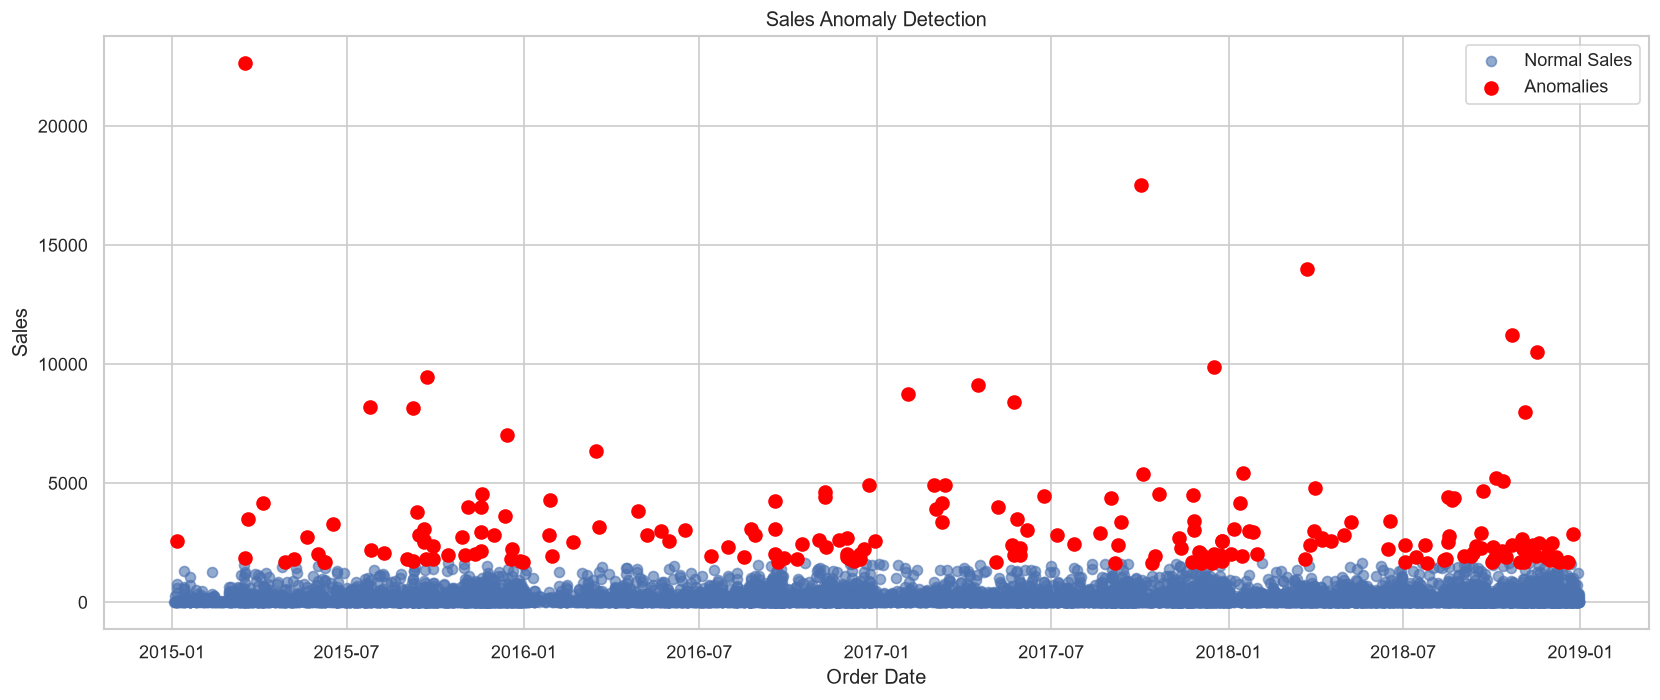

In [79]:
# ==========================================================
# Sales Anomaly Detection
# ==========================================================

plt.figure(figsize=(14,6))

plt.scatter(
    sales_df["Order Date"],
    sales_df["Sales"],
    label="Normal Sales",
    alpha=0.6
)

anomalies = sales_df[
    sales_df["IF_Anomaly"]
]

plt.scatter(
    anomalies["Order Date"],
    anomalies["Sales"],
    color="red",
    s=60,
    label="Anomalies"
)

plt.title("Sales Anomaly Detection")

plt.xlabel("Order Date")

plt.ylabel("Sales")

plt.legend()

plt.tight_layout()

plt.show()

In [80]:
# ==========================================================
# Anomalous Transactions
# ==========================================================

sales_df[
    sales_df["IF_Anomaly"]
]

,Order Date,Sales,Z-Score,Z_Anomaly,IF_Anomaly
10,2015-06-09,1706.184,2.354561,False,True
27,2016-09-17,3083.430,4.552458,True,True
149,2017-12-05,1951.840,2.746595,False,True
165,2015-09-08,8159.952,12.653896,True,True
167,2015-09-08,1740.060,2.408623,False,True
...,...,...,...,...,...
9639,2016-01-28,4297.644,6.490178,True,True
9649,2017-11-26,3406.664,5.068296,True,True
9660,2017-06-06,3023.928,4.457501,True,True
9741,2016-11-08,4404.900,6.661344,True,True


In [82]:
print("""
Business Insights

1. The Z-Score method identified 123 unusually high or low sales transactions based on statistical deviation.

2. Isolation Forest detected 196 anomalous transactions by identifying observations that differed significantly from normal sales patterns.

3. These anomalies may represent bulk purchases, seasonal demand spikes, promotional campaigns, or potential data quality issues that require further investigation.

4. Identifying unusual sales patterns helps improve forecasting accuracy, optimize inventory planning, and enables businesses to investigate suspicious or exceptional transactions.
""")


Business Insights

1. The Z-Score method identified 123 unusually high or low sales transactions based on statistical deviation.

2. Isolation Forest detected 196 anomalous transactions by identifying observations that differed significantly from normal sales patterns.

3. These anomalies may represent bulk purchases, seasonal demand spikes, promotional campaigns, or potential data quality issues that require further investigation.

4. Identifying unusual sales patterns helps improve forecasting accuracy, optimize inventory planning, and enables businesses to investigate suspicious or exceptional transactions.



# Task 6: Product Demand Segmentation using K-Means Clustering

In this task, product sub-categories are segmented into different demand groups using K-Means clustering. The segmentation is based on sales performance, growth, volatility, and average order value to support inventory and stocking decisions.


In [83]:
# ==========================================================
# Aggregate Product Demand Features
# ==========================================================

product_features = (
    df.groupby("Sub-Category")
      .agg(
          Total_Sales=("Sales", "sum"),
          Average_Order_Value=("Sales", "mean")
      )
)

product_features.head()

,Total_Sales,Average_Order_Value
Sub-Category,,
Accessories,164186.7000,217.178175
Appliances,104618.4030,227.926804
Art,26705.4100,34.019631
Binders,200028.7850,134.067550
Bookcases,113813.1987,503.598224


In [84]:
# ==========================================================
# Monthly Sales by Product Sub-Category
# ==========================================================

monthly_product_sales = (
    df.groupby(
        [
            pd.Grouper(key="Order Date", freq="ME"),
            "Sub-Category"
        ]
    )["Sales"]
    .sum()
    .reset_index()
)

monthly_product_sales.head()

,Order Date,Sub-Category,Sales
0,2015-01-31,Accessories,827.890
1,2015-01-31,Appliances,312.580
2,2015-01-31,Art,176.990
3,2015-01-31,Binders,814.508
4,2015-01-31,Bookcases,1010.055


In [85]:
# ==========================================================
# Sales Volatility
# ==========================================================

volatility = (
    monthly_product_sales
    .groupby("Sub-Category")["Sales"]
    .std()
)

product_features["Sales_Volatility"] = volatility

In [86]:
# ==========================================================
# Sales Growth Rate
# ==========================================================

monthly_product_sales["Year"] = (
    monthly_product_sales["Order Date"].dt.year
)

yearly_sales = (
    monthly_product_sales
    .groupby(
        ["Sub-Category", "Year"]
    )["Sales"]
    .sum()
    .unstack(fill_value=0)
)

growth = (
    (yearly_sales.iloc[:, -1] - yearly_sales.iloc[:, 0])
    /
    yearly_sales.iloc[:, 0]
) * 100

product_features["Sales_Growth"] = growth

In [87]:
# ==========================================================
# Fill Missing Values
# ==========================================================

product_features = product_features.fillna(0)

product_features.head()

,Total_Sales,Average_Order_Value,Sales_Volatility,Sales_Growth
Sub-Category,,,,
Accessories,164186.7000,217.178175,2579.994809,145.055961
Appliances,104618.4030,227.926804,1821.621539,165.242912
Art,26705.4100,34.019631,330.488343,49.649531
Binders,200028.7850,134.067550,3848.223648,65.778638
Bookcases,113813.1987,503.598224,2220.405080,49.846598


In [88]:
# ==========================================================
# Feature Scaling
# ==========================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(product_features)

In [89]:
# ==========================================================
# Elbow Method
# ==========================================================

from sklearn.cluster import KMeans

wcss = []

for k in range(1, 8):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_features)

    wcss.append(model.inertia_)

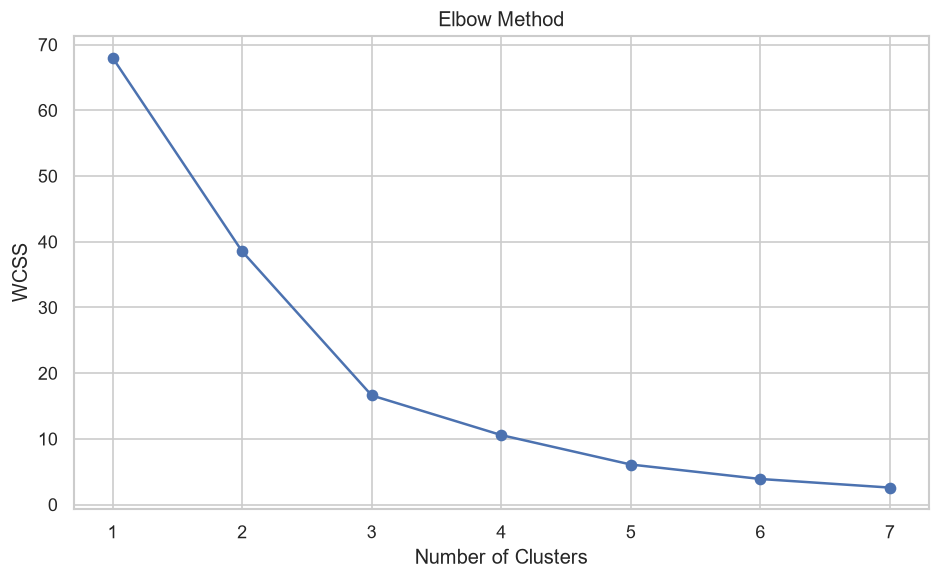


Observation

The Elbow Method indicates that the optimal number of clusters is 3.
After K=3, the reduction in WCSS becomes much smaller, indicating diminishing returns from adding more clusters.
Therefore, K-Means clustering will be performed using 3 clusters.



In [91]:
# ==========================================================
# Elbow Curve
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(
    range(1,8),
    wcss,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.tight_layout()

plt.show()

print("""
Observation

The Elbow Method indicates that the optimal number of clusters is 3.
After K=3, the reduction in WCSS becomes much smaller, indicating diminishing returns from adding more clusters.
Therefore, K-Means clustering will be performed using 3 clusters.
""")

In [92]:
# ==========================================================
# Apply K-Means Clustering
# ==========================================================

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

product_features["Cluster"] = kmeans.fit_predict(scaled_features)

product_features.head()

,Total_Sales,Average_Order_Value,Sales_Volatility,Sales_Growth,Cluster
Sub-Category,,,,,
Accessories,164186.7000,217.178175,2579.994809,145.055961,1
Appliances,104618.4030,227.926804,1821.621539,165.242912,1
Art,26705.4100,34.019631,330.488343,49.649531,1
Binders,200028.7850,134.067550,3848.223648,65.778638,2
Bookcases,113813.1987,503.598224,2220.405080,49.846598,1


In [93]:
# ==========================================================
# Reduce Dimensions using PCA
# ==========================================================

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled_features)

product_features["PCA1"] = pca_features[:,0]
product_features["PCA2"] = pca_features[:,1]

product_features.head()

,Total_Sales,Average_Order_Value,Sales_Volatility,Sales_Growth,Cluster,PCA1,PCA2
Sub-Category,,,,,,,
Accessories,164186.7000,217.178175,2579.994809,145.055961,1,0.200367,0.116729
Appliances,104618.4030,227.926804,1821.621539,165.242912,1,-0.264248,0.707660
Art,26705.4100,34.019631,330.488343,49.649531,1,-1.676784,0.535820
Binders,200028.7850,134.067550,3848.223648,65.778638,2,0.484161,-0.805597
Bookcases,113813.1987,503.598224,2220.405080,49.846598,1,-0.176589,0.003166


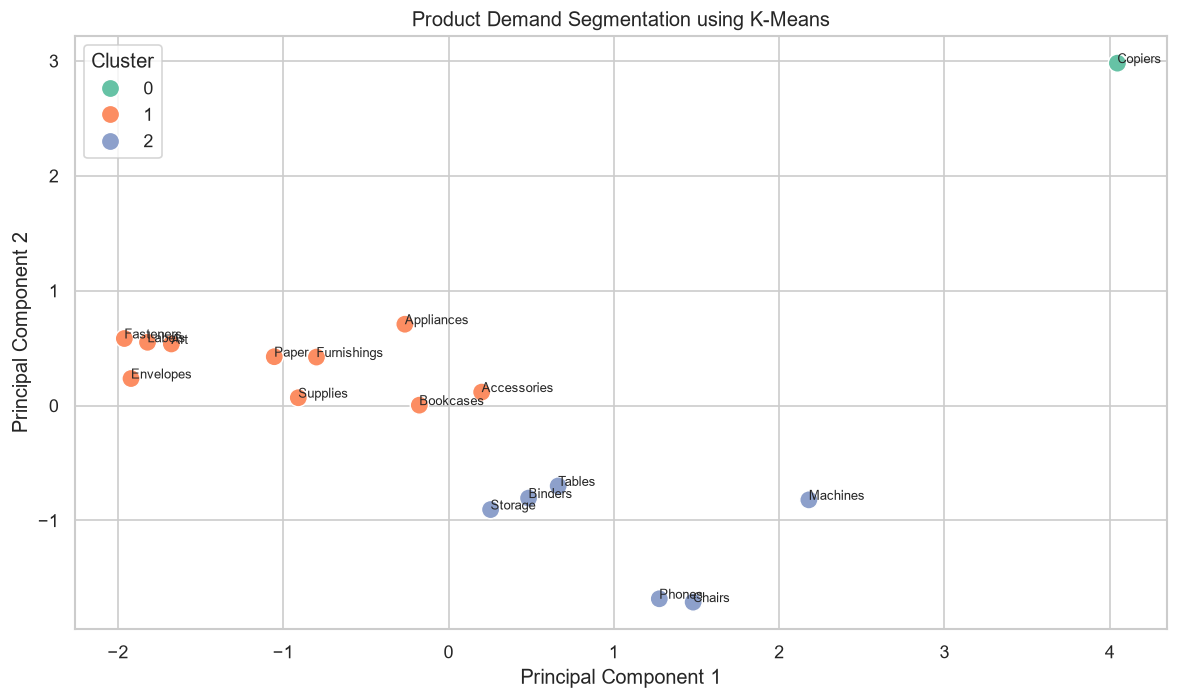

In [94]:
# ==========================================================
# Product Demand Clusters
# ==========================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=product_features,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="Set2",
    s=120
)

# Display product names
for sub_category in product_features.index:
    plt.text(
        product_features.loc[sub_category, "PCA1"],
        product_features.loc[sub_category, "PCA2"],
        sub_category,
        fontsize=8
    )

plt.title("Product Demand Segmentation using K-Means")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title="Cluster")

plt.tight_layout()

plt.show()

In [95]:
# ==========================================================
# Products in Each Cluster
# ==========================================================

product_features[
    [
        "Total_Sales",
        "Average_Order_Value",
        "Sales_Volatility",
        "Sales_Growth",
        "Cluster"
    ]
].sort_values("Cluster")

,Total_Sales,Average_Order_Value,Sales_Volatility,Sales_Growth,Cluster
Sub-Category,,,,,
Copiers,146248.0940,2215.880212,5500.774391,479.729510,0
Accessories,164186.7000,217.178175,2579.994809,145.055961,1
Art,26705.4100,34.019631,330.488343,49.649531,1
Appliances,104618.4030,227.926804,1821.621539,165.242912,1
Envelopes,16128.0460,65.032444,228.218688,-12.121345,1
Bookcases,113813.1987,503.598224,2220.405080,49.846598,1
Furnishings,89212.0180,95.823865,1360.017867,106.824969,1
Fasteners,3001.9600,14.027850,48.742229,30.468364,1
Supplies,46420.3080,252.284283,2025.094139,11.276038,1


In [96]:
# ==========================================================
# Cluster Summary
# ==========================================================

cluster_summary = (
    product_features
    .groupby("Cluster")
    .mean(numeric_only=True)
)

cluster_summary

,Total_Sales,Average_Order_Value,Sales_Volatility,Sales_Growth,PCA1,PCA2
Cluster,,,,,,
0,146248.09400,2215.880212,5500.774391,479.729510,4.046026,2.979941
1,65326.20737,150.189900,1186.287889,67.421837,-1.038176,0.364604
2,243671.10250,599.193752,3992.982732,27.323655,1.055956,-1.104330


In [97]:
# ==========================================================
# Assign Business Labels
# ==========================================================

cluster_names = {
    0: "High Value, High Growth",
    1: "Low Demand, Stable",
    2: "High Volume, Established"
}

product_features["Demand_Segment"] = (
    product_features["Cluster"].map(cluster_names)
)

product_features[
    [
        "Total_Sales",
        "Average_Order_Value",
        "Sales_Volatility",
        "Sales_Growth",
        "Demand_Segment"
    ]
]

,Total_Sales,Average_Order_Value,Sales_Volatility,Sales_Growth,Demand_Segment
Sub-Category,,,,,
Accessories,164186.7000,217.178175,2579.994809,145.055961,"Low Demand, Stable"
Appliances,104618.4030,227.926804,1821.621539,165.242912,"Low Demand, Stable"
Art,26705.4100,34.019631,330.488343,49.649531,"Low Demand, Stable"
Binders,200028.7850,134.067550,3848.223648,65.778638,"High Volume, Established"
Bookcases,113813.1987,503.598224,2220.405080,49.846598,"Low Demand, Stable"
Chairs,322822.7310,531.833165,4407.232960,20.954677,"High Volume, Established"
Copiers,146248.0940,2215.880212,5500.774391,479.729510,"High Value, High Growth"
Envelopes,16128.0460,65.032444,228.218688,-12.121345,"Low Demand, Stable"
Fasteners,3001.9600,14.027850,48.742229,30.468364,"Low Demand, Stable"


In [98]:
# ==========================================================
# Stocking Strategy
# ==========================================================

print("""
Stocking Strategy

1. High Value, High Growth
   - Increase inventory gradually to meet growing demand.
   - Monitor sales frequently to avoid stockouts.

2. High Volume, Established
   - Maintain consistent inventory levels.
   - Prioritize supplier availability and replenishment planning.

3. Low Demand, Stable
   - Maintain limited stock levels.
   - Avoid overstocking and review product performance periodically.
""")


Stocking Strategy

1. High Value, High Growth
   - Increase inventory gradually to meet growing demand.
   - Monitor sales frequently to avoid stockouts.

2. High Volume, Established
   - Maintain consistent inventory levels.
   - Prioritize supplier availability and replenishment planning.

3. Low Demand, Stable
   - Maintain limited stock levels.
   - Avoid overstocking and review product performance periodically.



In [99]:
print("""
Business Insights

1. K-Means clustering segmented product sub-categories into three distinct demand groups using sales volume, growth rate, sales volatility, and average order value.

2. High Value, High Growth products represent emerging opportunities and should receive increased inventory investment to support future demand.

3. High Volume, Established products consistently generate the highest sales and require reliable replenishment strategies to prevent stock shortages.

4. Low Demand, Stable products contribute relatively lower sales and should be managed with lean inventory policies to reduce holding costs.

5. Product demand segmentation enables businesses to optimize inventory planning, improve supply chain efficiency, and allocate resources based on demand characteristics.
""")


Business Insights

1. K-Means clustering segmented product sub-categories into three distinct demand groups using sales volume, growth rate, sales volatility, and average order value.

2. High Value, High Growth products represent emerging opportunities and should receive increased inventory investment to support future demand.

3. High Volume, Established products consistently generate the highest sales and require reliable replenishment strategies to prevent stock shortages.

4. Low Demand, Stable products contribute relatively lower sales and should be managed with lean inventory policies to reduce holding costs.

5. Product demand segmentation enables businesses to optimize inventory planning, improve supply chain efficiency, and allocate resources based on demand characteristics.



In [100]:
# ==========================================================
# Final Product Demand Segments
# ==========================================================

product_features.sort_values("Demand_Segment")

,Total_Sales,Average_Order_Value,Sales_Volatility,Sales_Growth,Cluster,PCA1,PCA2,Demand_Segment
Sub-Category,,,,,,,,
Copiers,146248.0940,2215.880212,5500.774391,479.729510,0,4.046026,2.979941,"High Value, High Growth"
Tables,202810.6280,645.893720,3224.082504,33.078016,2,0.663161,-0.700053,"High Volume, Established"
Storage,219343.3920,263.633885,2822.084310,38.366108,2,0.254384,-0.905577,"High Volume, Established"
Phones,327782.4480,374.180877,4052.718221,35.557607,2,1.274893,-1.682174,"High Volume, Established"
Binders,200028.7850,134.067550,3848.223648,65.778638,2,0.484161,-0.805597,"High Volume, Established"
Chairs,322822.7310,531.833165,4407.232960,20.954677,2,1.479554,-1.711393,"High Volume, Established"
Machines,189238.6310,1645.553313,5603.554747,-29.793120,2,2.179582,-0.821189,"High Volume, Established"
Paper,76828.3040,57.420257,1024.824982,91.901971,1,-1.054223,0.424876,"Low Demand, Stable"
Labels,12347.7260,34.587468,223.471218,36.073373,1,-1.820825,0.550340,"Low Demand, Stable"
